# **Задание 1**

In [ ]:
! pip install cvxopt

In [ ]:
import numpy as np
from cvxopt import matrix, solvers

# Creating matrix
P = matrix(np.array([[2., 0.], [0., 8.]]))
q = matrix(np.array([-8., -16.]))

# Матрица ограничений G (4 ограничения × 2 переменные)
G = matrix(np.array([
    [1., 1.],    # x1 + x2 ≤ 5
    [1., 0.],    # x1 ≤ 3
    [-1., 0.],   # -x1 ≤ 0 (эквивалентно x1 ≥ 0)
    [0., -1.]    # -x2 ≤ 0 (эквивалентно x2 ≥ 0)
]))

h = matrix(np.array([5., 3., 0., 0.]))

# Решение
sol = solvers.qp(P, q, G, h)
solvers.options['show_progress'] = False
print(np.array(sol['x']),np.array(sol['x']))

x1, x2 = sol['x'][0], sol['x'][1]
print(f"Точка оптимума: x1 = {x1:.10f}, x2 = {x2:.10f}")
print(f"Значение функции: {sol['primal objective']:.10f}")


# Info for question 'Какие из ограничений-неравенств задачи являются активными, т.е. влияют на точку оптимума, а какие ограничения можно выбросить и точка оптимума не поменяется?'
print(f"\nТочная проверка ограничений:")
print(f"x1 + x2 = {x1 + x2:.10f} ≤ 5: {'АКТИВНО' if abs(x1 + x2 - 5) < 1e-8 else 'неактивно'}")
print(f"x1 = {x1:.10f} ≤ 3: {'АКТИВНО' if abs(x1 - 3) < 1e-8 else 'активно'}")
print(f"x1 = {x1:.10f} ≥ 0: {'АКТИВНО' if abs(x1) < 1e-8 else 'неактивно'}")
print(f"x2 = {x2:.10f} ≥ 0: {'АКТИВНО' if abs(x2) < 1e-8 else 'неактивно'}")

[[2.99999983]
 [1.99869093]] [[2.99999983]
 [1.99869093]]
Точка оптимума: x1 = 2.9999998301, x2 = 1.9986909285
Значение функции: -30.9999928055

Точная проверка ограничений:
x1 + x2 = 4.9986907586 ≤ 5: неактивно
x1 = 2.9999998301 ≤ 3: активно
x1 = 2.9999998301 ≥ 0: неактивно
x2 = 1.9986909285 ≥ 0: неактивно


# **Задание 2**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.preprocessing import StandardScaler

# Настройка для отключения вывода процесса решения
solvers.options['show_progress'] = False

# Генерация всех данных
np.random.seed(42)

# 1. Линейно-разделимая выборка
X_linear, y_linear = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                        n_informative=2, n_clusters_per_class=1,
                                        class_sep=1.5, random_state=42)
y_linear = 2 * y_linear - 1  # преобразуем в {-1, +1}

# 2. Нелинейно-разделимая
X_moons, y_moons = make_moons(n_samples=100, noise=0.1, random_state=42)
y_moons = 2 * y_moons - 1

# 3. Плохо разделимая выборка
X_overlap, y_overlap = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                          n_informative=2, n_clusters_per_class=1,
                                          class_sep=0.5, random_state=42)
y_overlap = 2 * y_overlap - 1

# Масштабирование
scaler = StandardScaler()
X_linear = scaler.fit_transform(X_linear)
X_moons = scaler.fit_transform(X_moons)
X_overlap = scaler.fit_transform(X_overlap)

print("Данные сгенерированы")
print(f"Линейно-разделимая: {X_linear.shape}")
print(f"Нелинейная: {X_moons.shape}")
print(f"Плохо разделимая: {X_overlap.shape}")

Данные сгенерированы!
Линейно-разделимая: (100, 2)
Нелинейная: (100, 2)
Плохо разделимая: (100, 2)


Определяю класс LinearSVM

In [ ]:
class LinearSVM:
    def __init__(self, C=1.0):
        self.C = C

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Приведение к форме QP: min ½xᵀPx + qᵀx
        # x = [w, b, ξ]

        # P = diag([1, 1, ..., 1, 0, 0, ..., 0])
        P = np.zeros((n_features + 1 + n_samples, n_features + 1 + n_samples))
        for i in range(n_features):
            P[i, i] = 1.0
        P = matrix(P)

        # q = [0, 0, ..., 0, C, C, ..., C]
        q = np.zeros(n_features + 1 + n_samples)
        q[n_features + 1:] = self.C
        q = matrix(q)

        # Ограничения: yₙ(wᵀxₙ + b) ≥ 1 - ξₙ
        G1 = np.zeros((n_samples, n_features + 1 + n_samples))
        for i in range(n_samples):
            G1[i, :n_features] = -y[i] * X[i]
            G1[i, n_features] = -y[i]  # для b
            G1[i, n_features + 1 + i] = -1  # для ξᵢ

        h1 = -np.ones(n_samples)

        # Ограничения: ξₙ ≥ 0 → -ξₙ ≤ 0
        G2 = np.zeros((n_samples, n_features + 1 + n_samples))
        for i in range(n_samples):
            G2[i, n_features + 1 + i] = -1

        h2 = np.zeros(n_samples)

        # Объединяем ограничения
        G = matrix(np.vstack([G1, G2]))
        h = matrix(np.hstack([h1, h2]))

        # Решаем QP
        sol = solvers.qp(P, q, G, h)
        solution = np.array(sol['x']).flatten()

        self.w = solution[:n_features]
        self.b = solution[n_features]
        self.xi = solution[n_features + 1:]

        # Находим опорные векторы
        self.support_vectors = []
        margin = 1e-4
        for i in range(n_samples):
            if abs(y[i] * (X[i] @ self.w + self.b) - (1 - self.xi[i])) < margin:
                self.support_vectors.append(i)

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

    def decision_function(self, X):
        return X @ self.w + self.b

# Функция для визуализации
def plot_svm(X, y, model, title):
    plt.figure(figsize=(10, 8))

    # Разделяющая прямая и границы
    xx = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
    yy = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100)
    XX, YY = np.meshgrid(xx, yy)
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

    # Контуры
    plt.contour(XX, YY, Z, levels=[-1, 0, 1], colors=['red', 'black', 'blue'],
                linestyles=['--', '-', '--'], linewidths=2)
    plt.contourf(XX, YY, Z, levels=50, alpha=0.3, cmap=plt.cm.RdBu)

    # Данные
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class +1', alpha=0.7)
    plt.scatter(X[y == -1, 0], X[y == -1, 1], c='red', label='Class -1', alpha=0.7)

    # Опорные векторы
    if hasattr(model, 'support_vectors') and model.support_vectors:
        sv_indices = model.support_vectors
        plt.scatter(X[sv_indices, 0], X[sv_indices, 1],
                   s=150, facecolors='none', edgecolors='green',
                   linewidth=2, label='Support Vectors')

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

Теперь протестируем линейный SVM на всех выборках:

ЛИНЕЙНО-РАЗДЕЛИМАЯ ВЫБОРКА


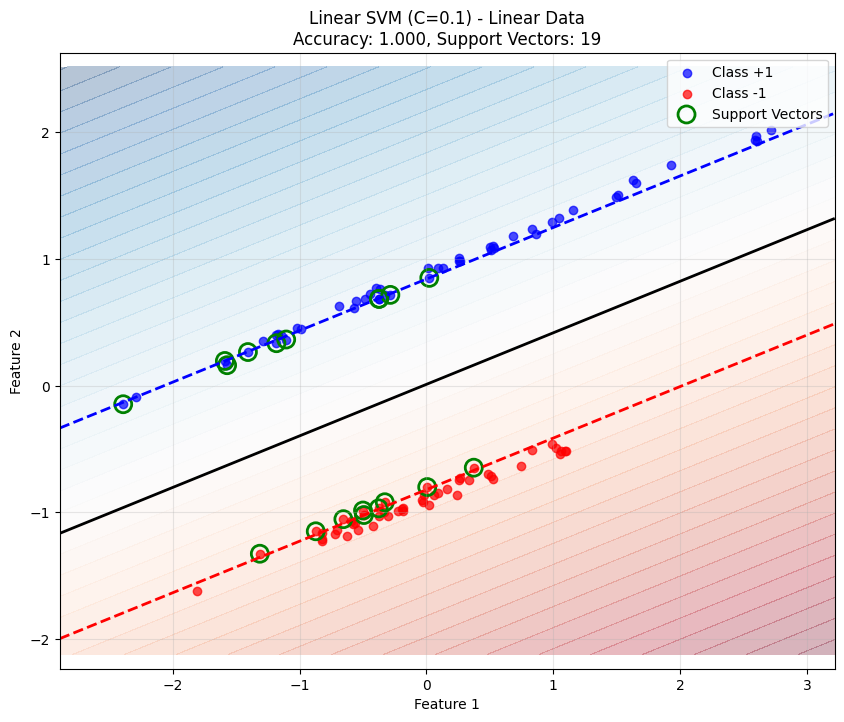

C=0.1: 19 опорных векторов, точность: 1.000


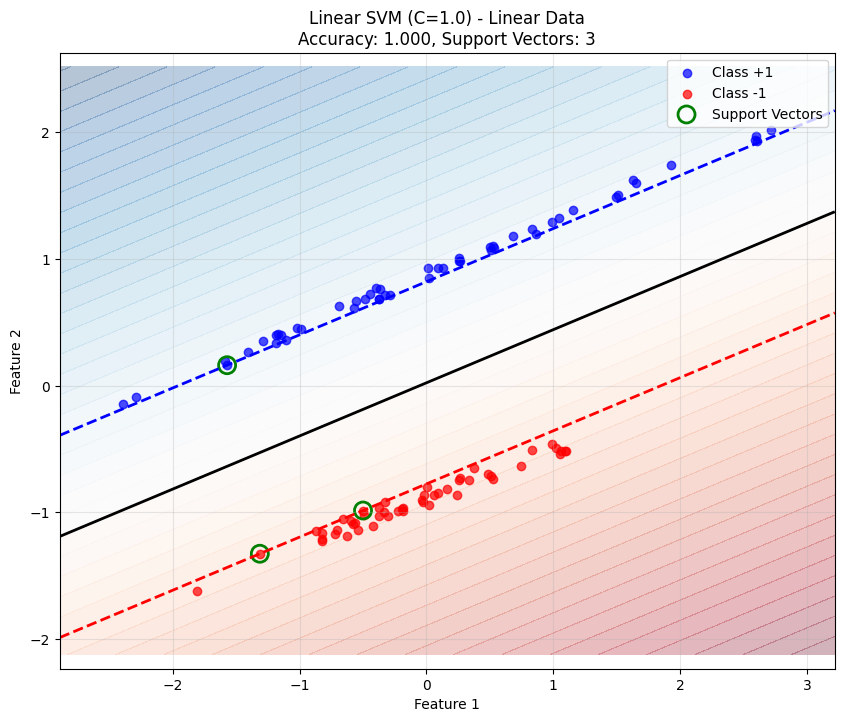

C=1.0: 3 опорных векторов, точность: 1.000


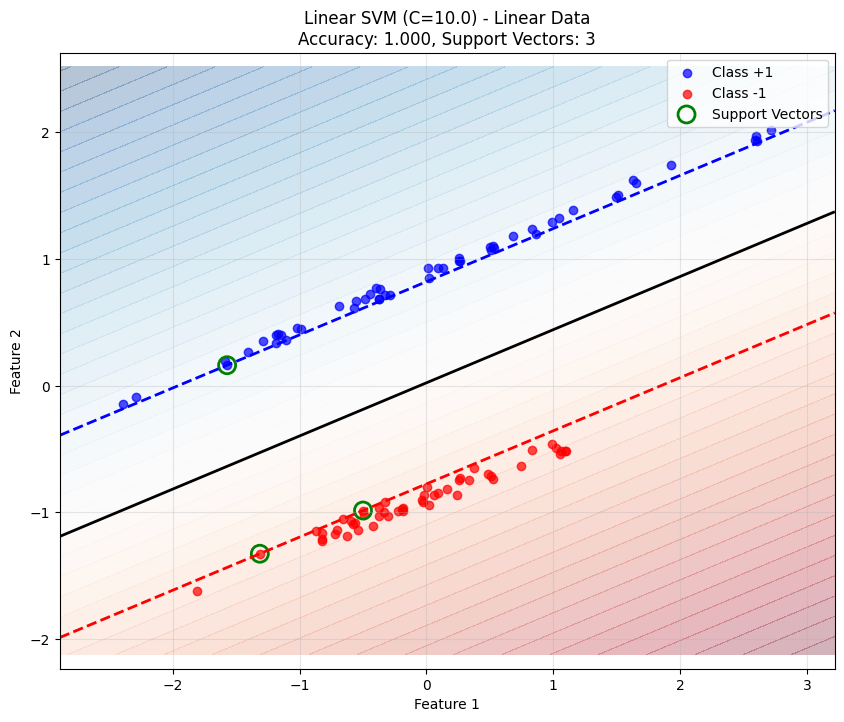

C=10.0: 3 опорных векторов, точность: 1.000

НЕЛИНЕЙНАЯ ВЫБОРКА


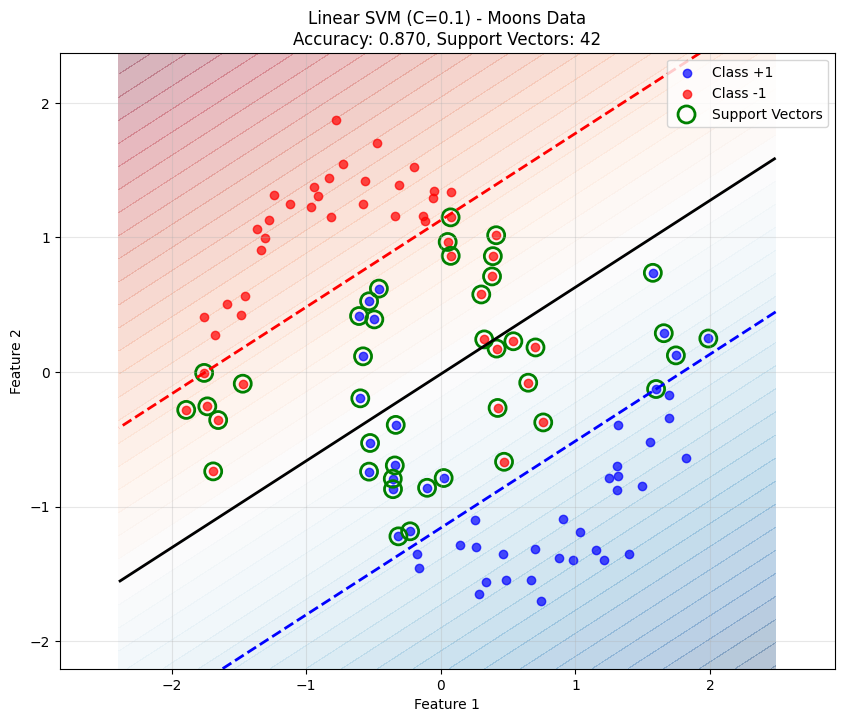

C=0.1: 42 опорных векторов, точность: 0.870


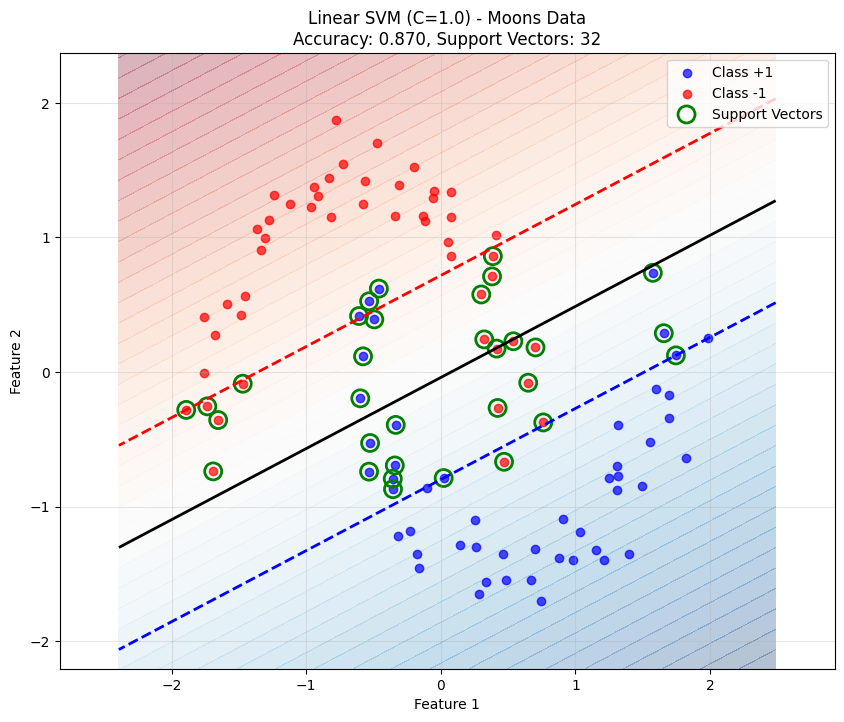

C=1.0: 32 опорных векторов, точность: 0.870


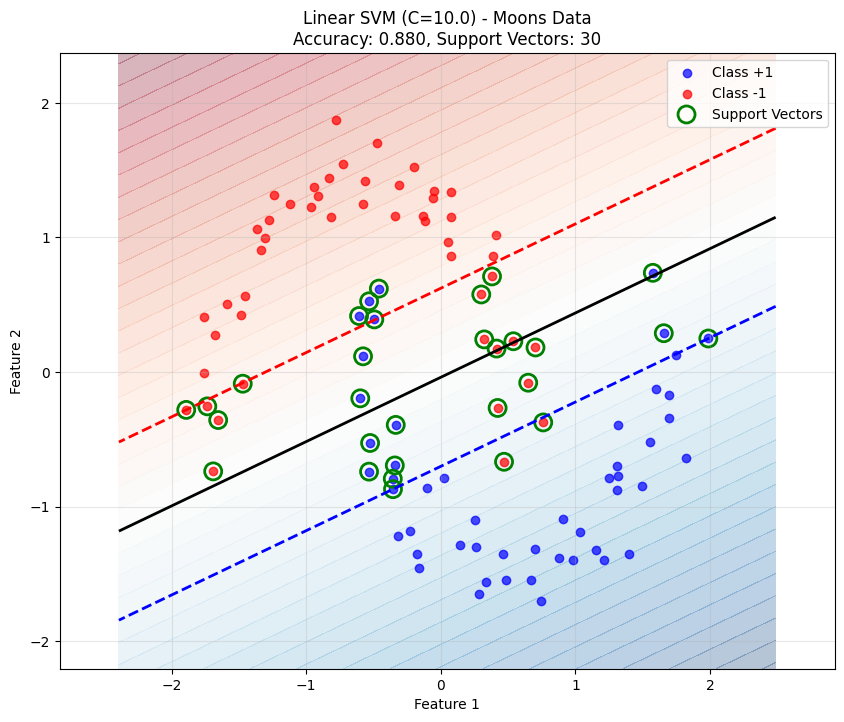

C=10.0: 30 опорных векторов, точность: 0.880

 ПЛОХО РАЗДЕЛИМАЯ ВЫБОРКА 


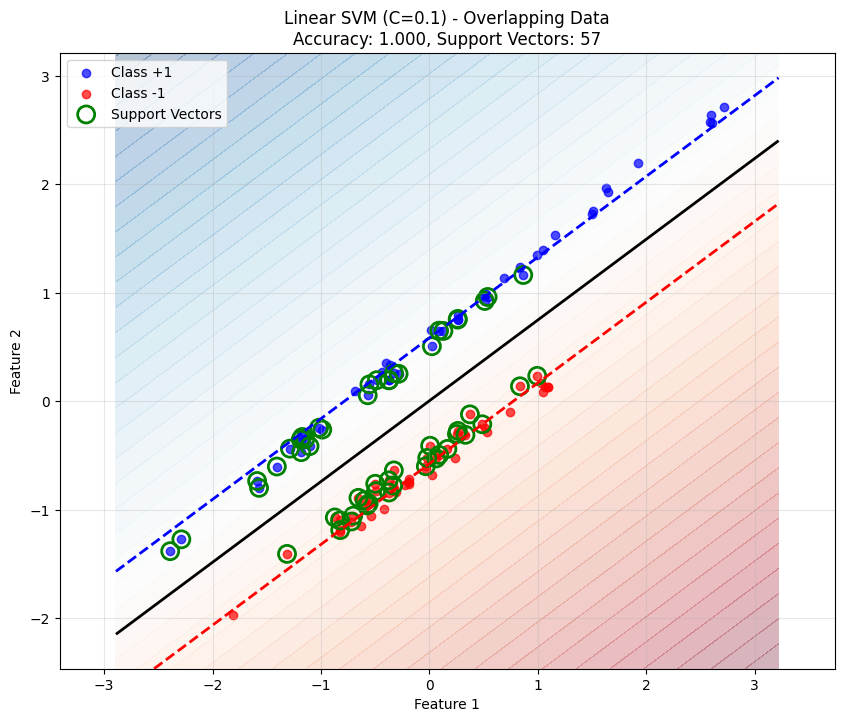

C=0.1: 57 опорных векторов, точность: 1.000


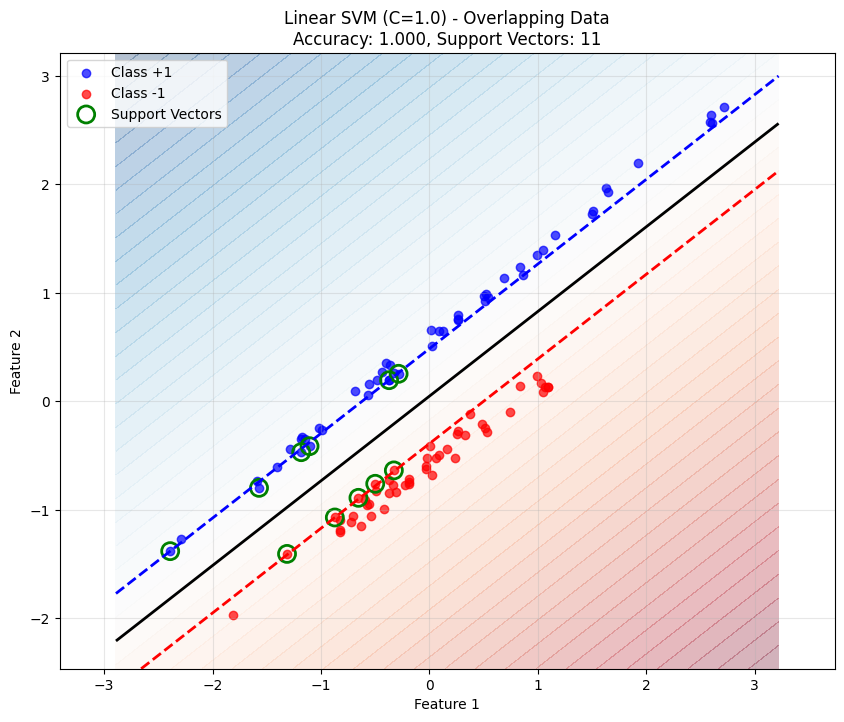

C=1.0: 11 опорных векторов, точность: 1.000


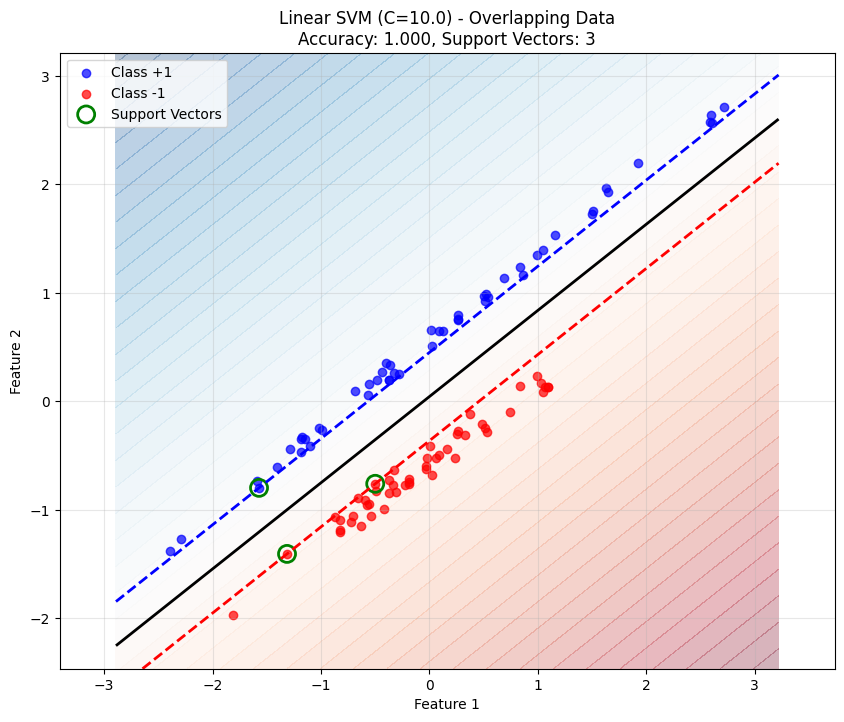

C=10.0: 3 опорных векторов, точность: 1.000


In [ ]:
# Тестирование на линейно-разделимой выборке
print("ЛИНЕЙНО-РАЗДЕЛИМАЯ ВЫБОРКА")
for C in [0.1, 1.0, 10.0]:
    svm = LinearSVM(C=C)
    svm.fit(X_linear, y_linear)
    accuracy = np.mean(svm.predict(X_linear) == y_linear)
    plot_svm(X_linear, y_linear, svm, f'Linear SVM (C={C}) - Linear Data\nAccuracy: {accuracy:.3f}, Support Vectors: {len(svm.support_vectors)}')
    print(f"C={C}: {len(svm.support_vectors)} опорных векторов, точность: {accuracy:.3f}")

# Тестирование на нелинейной выборке
print("\nНЕЛИНЕЙНАЯ ВЫБОРКА")
for C in [0.1, 1.0, 10.0]:
    svm = LinearSVM(C=C)
    svm.fit(X_moons, y_moons)
    accuracy = np.mean(svm.predict(X_moons) == y_moons)
    plot_svm(X_moons, y_moons, svm, f'Linear SVM (C={C}) - Moons Data\nAccuracy: {accuracy:.3f}, Support Vectors: {len(svm.support_vectors)}')
    print(f"C={C}: {len(svm.support_vectors)} опорных векторов, точность: {accuracy:.3f}")

# Тестирование на плохо разделимой выборке
print("\n ПЛОХО РАЗДЕЛИМАЯ ВЫБОРКА ")
for C in [0.1, 1.0, 10.0]:
    svm = LinearSVM(C=C)
    svm.fit(X_overlap, y_overlap)
    accuracy = np.mean(svm.predict(X_overlap) == y_overlap)
    plot_svm(X_overlap, y_overlap, svm, f'Linear SVM (C={C}) - Overlapping Data\nAccuracy: {accuracy:.3f}, Support Vectors: {len(svm.support_vectors)}')
    print(f"C={C}: {len(svm.support_vectors)} опорных векторов, точность: {accuracy:.3f}")

Теперь реализуем квадратичный SVM:


КВАДРАТИЧНЫЙ SVM НА НЕЛИНЕЙНЫХ ДАННЫХ


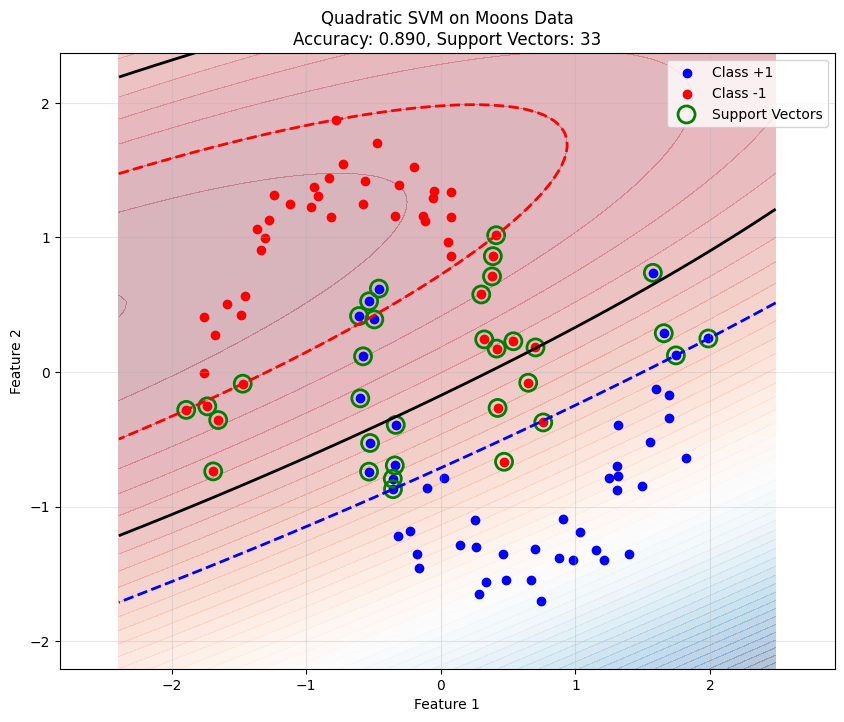

Квадратичный SVM: 33 опорных векторов, точность: 0.890


In [ ]:
class QuadraticSVM:
    def __init__(self, C=1.0):
        self.C = C

    def _quadratic_features(self, X):
        """Преобразование в квадратичные признаки: [x1, x2, x1², x1x2, x2²]"""
        n_samples = X.shape[0]
        X_quad = np.zeros((n_samples, 5))
        X_quad[:, 0] = X[:, 0]  # x1
        X_quad[:, 1] = X[:, 1]  # x2
        X_quad[:, 2] = X[:, 0]**2  # x1²
        X_quad[:, 3] = X[:, 0] * X[:, 1]  # x1x2
        X_quad[:, 4] = X[:, 1]**2  # x2²
        return X_quad

    def fit(self, X, y):
        X_quad = self._quadratic_features(X)
        n_samples, n_features = X_quad.shape

        # P матрица для QP
        P = np.zeros((n_features + 1 + n_samples, n_features + 1 + n_samples))
        for i in range(n_features):
            P[i, i] = 1.0
        P = matrix(P)

        q = np.zeros(n_features + 1 + n_samples)
        q[n_features + 1:] = self.C
        q = matrix(q)

        # Ограничения
        G1 = np.zeros((n_samples, n_features + 1 + n_samples))
        for i in range(n_samples):
            G1[i, :n_features] = -y[i] * X_quad[i]
            G1[i, n_features] = -y[i]
            G1[i, n_features + 1 + i] = -1

        h1 = -np.ones(n_samples)

        G2 = np.zeros((n_samples, n_features + 1 + n_samples))
        for i in range(n_samples):
            G2[i, n_features + 1 + i] = -1

        h2 = np.zeros(n_samples)

        G = matrix(np.vstack([G1, G2]))
        h = matrix(np.hstack([h1, h2]))

        sol = solvers.qp(P, q, G, h)
        solution = np.array(sol['x']).flatten()

        self.w = solution[:n_features]
        self.b = solution[n_features]
        self.xi = solution[n_features + 1:]

        # Опорные векторы
        self.support_vectors = []
        margin = 1e-4
        for i in range(n_samples):
            if abs(y[i] * (X_quad[i] @ self.w + self.b) - (1 - self.xi[i])) < margin:
                self.support_vectors.append(i)

        self.X_original = X  # сохраняем для визуализации

    def decision_function(self, X):
        X_quad = self._quadratic_features(X)
        return X_quad @ self.w + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))

# Функция для визуализации квадратичного SVM
def plot_quadratic_svm(X, y, model, title):
    plt.figure(figsize=(10, 8))

    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100),
                         np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['red', 'black', 'blue'],
                linestyles=['--', '-', '--'], linewidths=2)
    plt.contourf(xx, yy, Z, levels=50, alpha=0.3, cmap=plt.cm.RdBu)

    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class +1')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], c='red', label='Class -1')

    if hasattr(model, 'support_vectors') and model.support_vectors:
        plt.scatter(X[model.support_vectors, 0], X[model.support_vectors, 1],
                   s=150, facecolors='none', edgecolors='green',
                   linewidth=2, label='Support Vectors')

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# Тестирование квадратичного SVM
print("\nКВАДРАТИЧНЫЙ SVM НА НЕЛИНЕЙНЫХ ДАННЫХ")
quad_svm = QuadraticSVM(C=1.0)
quad_svm.fit(X_moons, y_moons)
accuracy = np.mean(quad_svm.predict(X_moons) == y_moons)

plot_quadratic_svm(X_moons, y_moons, quad_svm,
                  f'Quadratic SVM on Moons Data\nAccuracy: {accuracy:.3f}, Support Vectors: {len(quad_svm.support_vectors)}')

print(f"Квадратичный SVM: {len(quad_svm.support_vectors)} опорных векторов, точность: {accuracy:.3f}")

# **Задание 3**

1. Реализация ядрового SVM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.preprocessing import StandardScaler

# Настройка солвера
solvers.options['show_progress'] = False

class KernelSVM:
    def __init__(self, C=1.0, kernel='rbf', degree=2, gamma=1.0):
        self.C = C
        self.kernel = kernel
        self.degree = degree
        self.gamma = gamma

    def _kernel(self, x1, x2):
        """Вычисление ядерной функции"""
        if self.kernel == 'linear':
            return x1 @ x2
        elif self.kernel == 'poly':
            return (self.gamma * (x1 @ x2) + 1) ** self.degree
        elif self.kernel == 'rbf':
            return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.X_train = X.copy()
        self.y_train = y.copy()

        # Вычисляем матрицу Грама
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = self._kernel(X[i], X[j])

        # Двойственная задача QP
        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))

        # Ограничения: 0 ≤ α ≤ C
        G = matrix(np.vstack([-np.eye(n_samples), np.eye(n_samples)]))
        h = matrix(np.hstack([np.zeros(n_samples), np.ones(n_samples) * self.C]))

        # Ограничение: ∑αₙyₙ = 0
        A = matrix(y.astype(float).reshape(1, -1))
        b = matrix(0.0)

        # Решение QP
        solution = solvers.qp(P, q, G, h, A, b)
        alpha = np.array(solution['x']).flatten()

        # Опорные векторы (α > 1e-5)
        sv_mask = alpha > 1e-5
        self.alpha = alpha[sv_mask]
        self.support_vectors = X[sv_mask]
        self.support_labels = y[sv_mask]

        # Вычисление b
        self.b = 0.0
        n_sv = 0
        for i in range(len(self.alpha)):
            if self.alpha[i] < self.C - 1e-5:  # строго опорные
                kernel_vals = np.array([self._kernel(self.support_vectors[i], sv)
                                      for sv in self.support_vectors])
                self.b += self.support_labels[i] - np.sum(self.alpha * self.support_labels * kernel_vals)
                n_sv += 1

        if n_sv > 0:
            self.b /= n_sv

    def decision_function(self, X):
        """Функция принятия решений"""
        y_pred = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            for j in range(len(self.alpha)):
                y_pred[i] += (self.alpha[j] * self.support_labels[j] *
                            self._kernel(X[i], self.support_vectors[j]))
        return y_pred + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))

2. Генерация данных и тестирование

In [ ]:
# Генерация различных выборок
np.random.seed(42)

# Линейно-разделимая
X_linear, y_linear = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                        n_clusters_per_class=1, class_sep=1.5, random_state=42)
y_linear = 2 * y_linear - 1

# Луны (нелинейная)
X_moons, y_moons = make_moons(n_samples=100, noise=0.1, random_state=42)
y_moons = 2 * y_moons - 1

# Круги (сложная нелинейность)
X_circles, y_circles = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=42)
y_circles = 2 * y_circles - 1

# Масштабирование
scaler = StandardScaler()
X_linear = scaler.fit_transform(X_linear)
X_moons = scaler.fit_transform(X_moons)
X_circles = scaler.fit_transform(X_circles)

print("Данные сгенерированы!")

Данные сгенерированы!


3. Функция для визуализации

In [ ]:
def plot_kernel_svm(X, y, model, title, ax=None):
    """Визуализация SVM с ядром"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Сетка для построения поверхностей
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 100),
                         np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 100))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Разделяющая поверхность и границы
    contour = ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                        colors=['red', 'black', 'blue'],
                        linestyles=['--', '-', '--'], linewidths=2)
    ax.contourf(xx, yy, Z, levels=50, alpha=0.3, cmap=plt.cm.RdBu)

    # Данные
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class +1', alpha=0.7)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c='red', label='Class -1', alpha=0.7)

    # Опорные векторы
    if hasattr(model, 'support_vectors') and len(model.support_vectors) > 0:
        ax.scatter(model.support_vectors[:, 0], model.support_vectors[:, 1],
                  s=150, facecolors='none', edgecolors='green',
                  linewidth=2, label='Support Vectors')

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

    return contour

4. Тестирование различных ядер

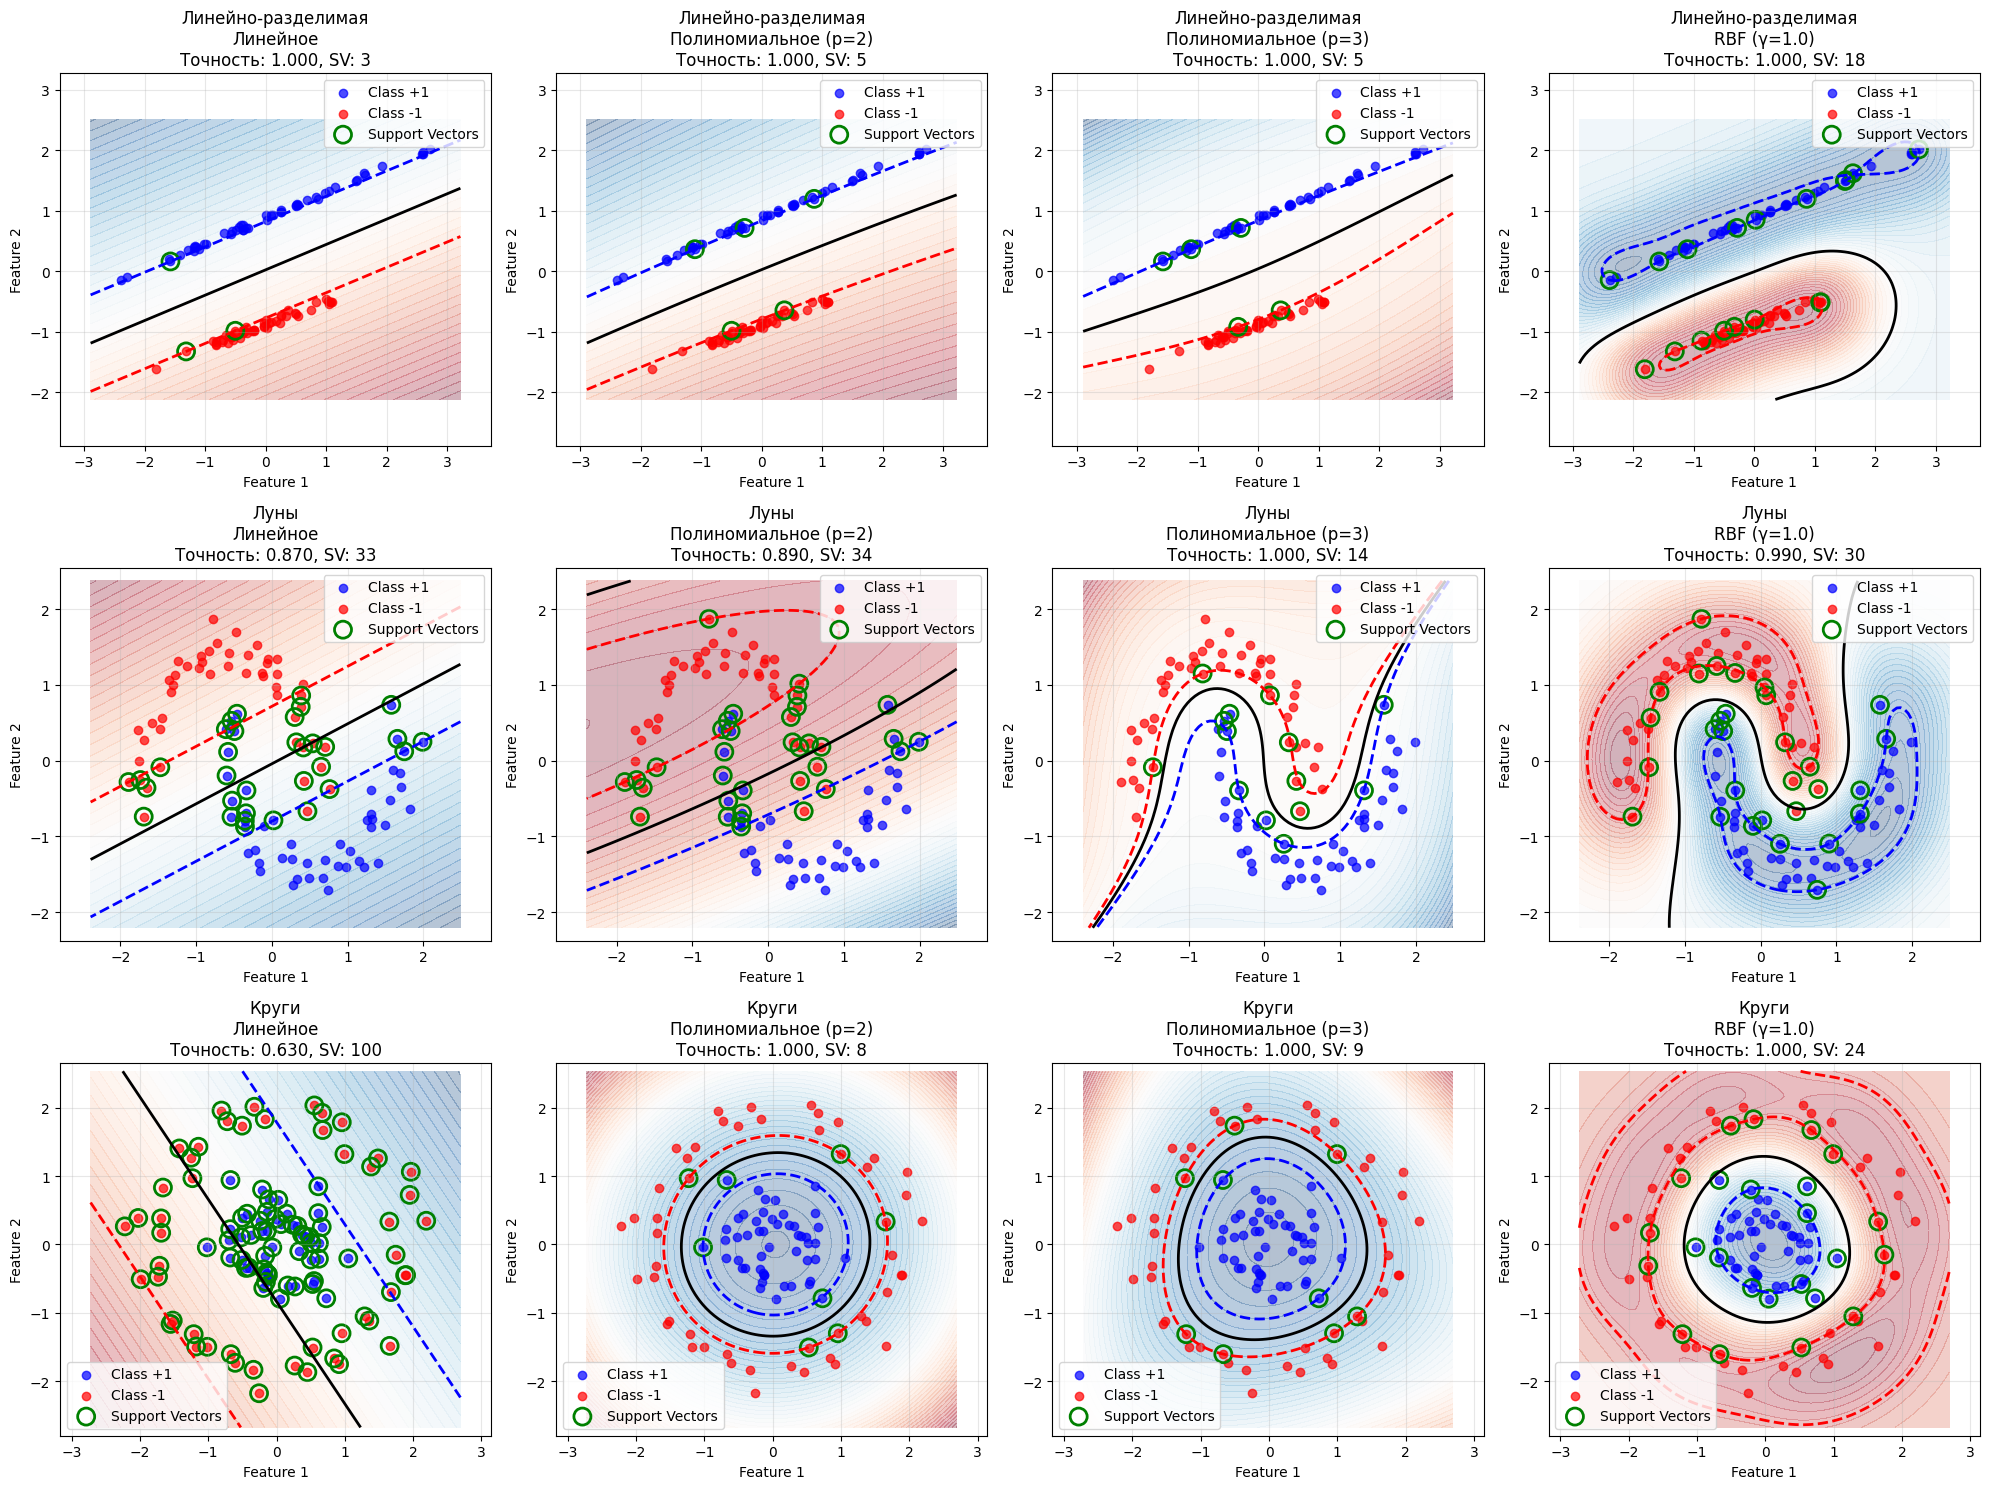

In [ ]:
# Тестирование на разных данных с разными ядрами
datasets = [
    (X_linear, y_linear, "Линейно-разделимая"),
    (X_moons, y_moons, "Луны"),
    (X_circles, y_circles, "Круги")
]

kernels = [
    ('linear', 'Линейное'),
    ('poly', 'Полиномиальное (p=2)'),
    ('poly', 'Полиномиальное (p=3)'),
    ('rbf', 'RBF (γ=1.0)')
]

kernel_params = [
    {'kernel': 'linear'},
    {'kernel': 'poly', 'degree': 2},
    {'kernel': 'poly', 'degree': 3},
    {'kernel': 'rbf', 'gamma': 1.0}
]

fig, axes = plt.subplots(len(datasets), len(kernels), figsize=(20, 15))

for i, (X, y, data_name) in enumerate(datasets):
    for j, (kernel_name, kernel_label) in enumerate(kernels):
        params = kernel_params[j].copy()
        svm = KernelSVM(C=1.0, **params)
        svm.fit(X, y)

        accuracy = np.mean(svm.predict(X) == y)
        title = f'{data_name}\n{kernel_label}\nТочность: {accuracy:.3f}, SV: {len(svm.support_vectors)}'

        plot_kernel_svm(X, y, svm, title, ax=axes[i, j])

plt.tight_layout()
plt.show()

5. Анализ полиномиального ядра

АНАЛИЗ ПОЛИНОМИАЛЬНОГО ЯДРА


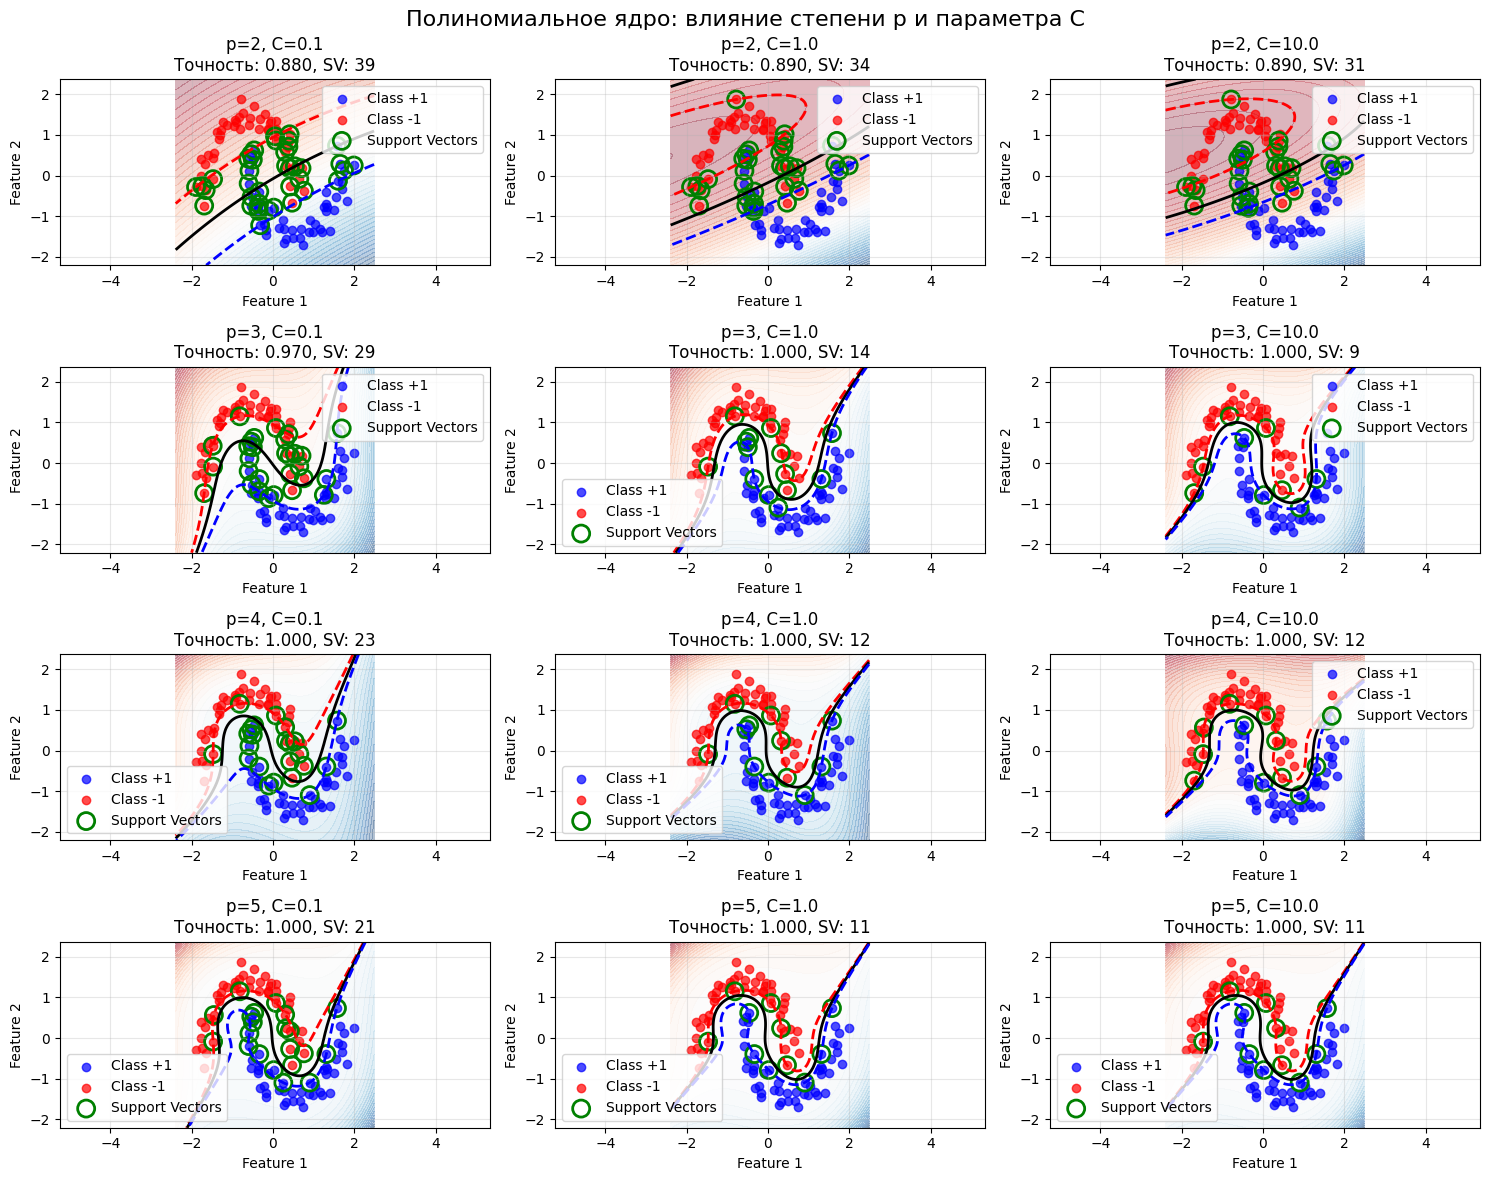


АНАЛИЗ ПОЛИНОМИАЛЬНОГО ЯДРА:
Степень p ↑ :
  - Разделяющая поверхность становится сложнее
  - Риск переобучения увеличивается
  - Требуется больше опорных векторов
  - Вычислительная сложность растет

Параметр C ↑ :
  - Меньше допускаются ошибки классификации
  - Разделяющая полоса уже
  - Меньше опорных векторов
  - Риск переобучения увеличивается


In [ ]:
# Влияние степени полинома и параметра C
print("АНАЛИЗ ПОЛИНОМИАЛЬНОГО ЯДРА")

degrees = [2, 3, 4, 5]
C_values = [0.1, 1.0, 10.0]

fig, axes = plt.subplots(len(degrees), len(C_values), figsize=(15, 12))

for i, degree in enumerate(degrees):
    for j, C in enumerate(C_values):
        svm = KernelSVM(C=C, kernel='poly', degree=degree, gamma=1.0)
        svm.fit(X_moons, y_moons)

        accuracy = np.mean(svm.predict(X_moons) == y_moons)
        title = f'p={degree}, C={C}\nТочность: {accuracy:.3f}, SV: {len(svm.support_vectors)}'

        plot_kernel_svm(X_moons, y_moons, svm, title, ax=axes[i, j])

plt.suptitle('Полиномиальное ядро: влияние степени p и параметра C', fontsize=16)
plt.tight_layout()
plt.show()

# Анализ поведения
print("\nАНАЛИЗ ПОЛИНОМИАЛЬНОГО ЯДРА:")
print("Степень p ↑ :")
print("  - Разделяющая поверхность становится сложнее")
print("  - Риск переобучения увеличивается")
print("  - Требуется больше опорных векторов")
print("  - Вычислительная сложность растет")

print("\nПараметр C ↑ :")
print("  - Меньше допускаются ошибки классификации")
print("  - Разделяющая полоса уже")
print("  - Меньше опорных векторов")
print("  - Риск переобучения увеличивается")

6. Анализ RBF ядра

АНАЛИЗ RBF ЯДРА


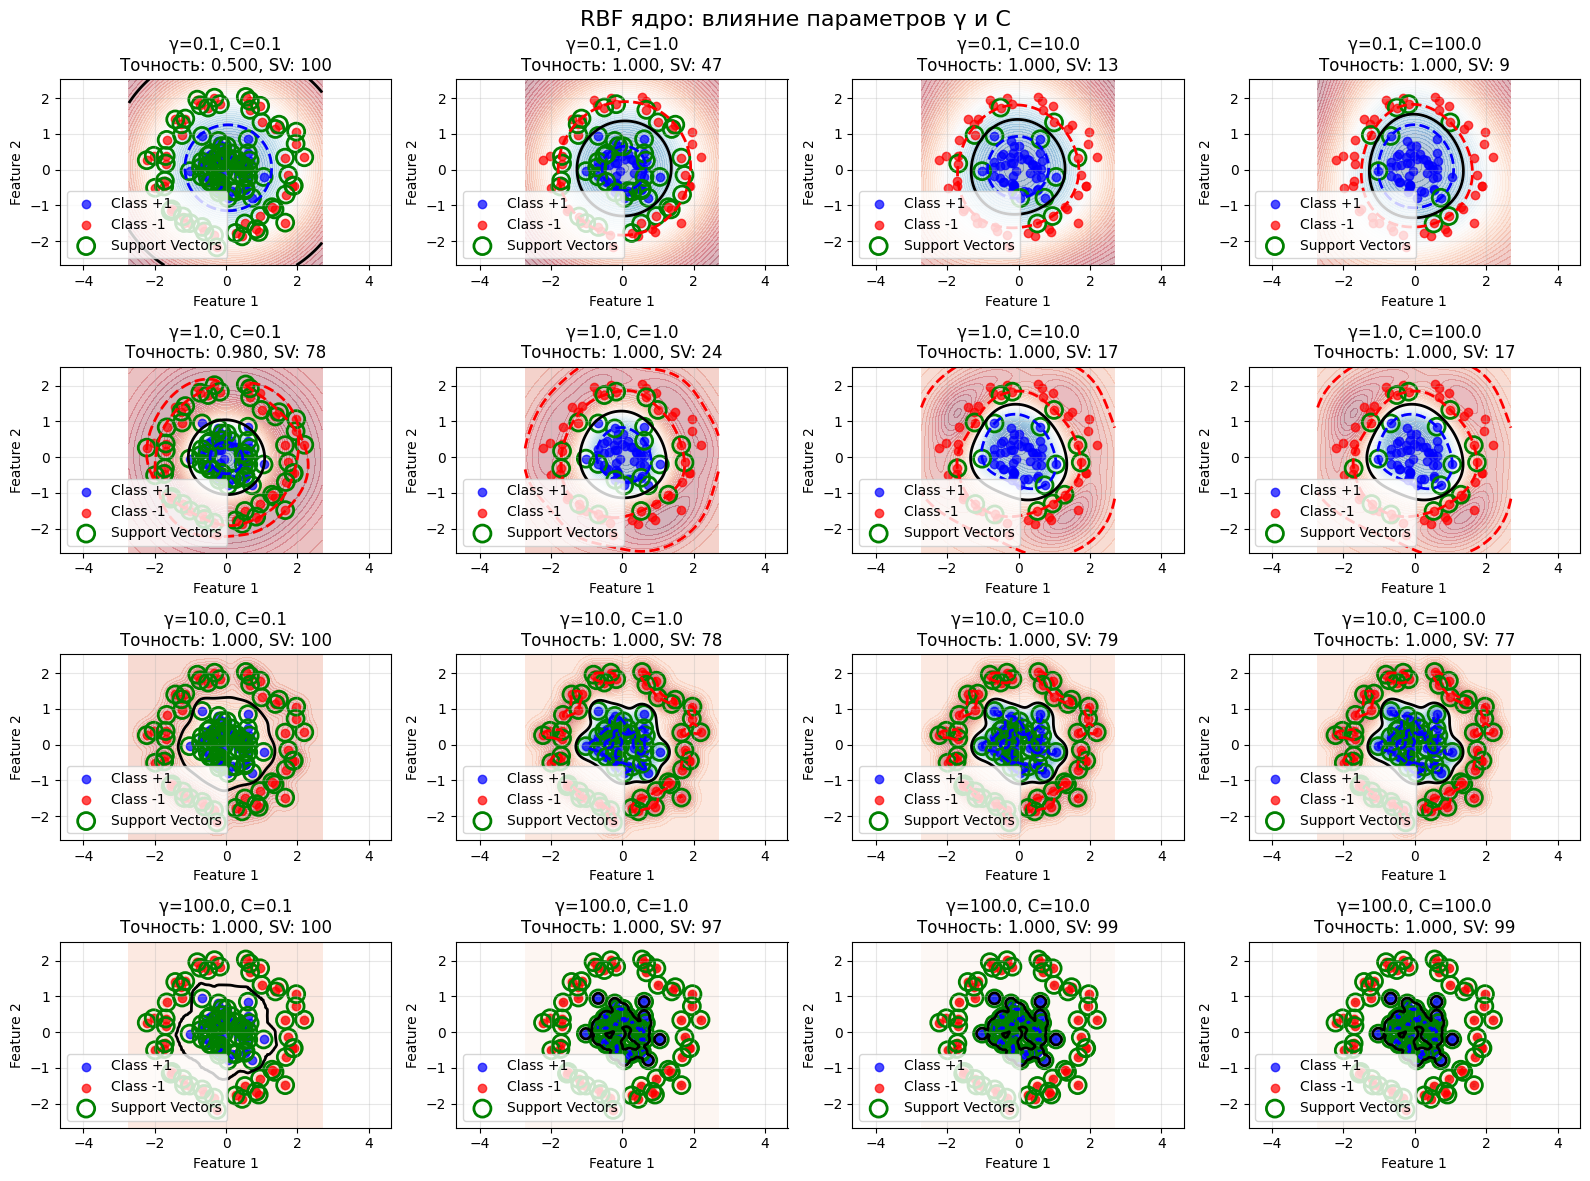

In [ ]:
# Влияние параметров γ и C для RBF ядра
print("АНАЛИЗ RBF ЯДРА")

gamma_values = [0.1, 1.0, 10.0, 100.0]
C_values = [0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(len(gamma_values), len(C_values), figsize=(16, 12))

for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        svm = KernelSVM(C=C, kernel='rbf', gamma=gamma)
        svm.fit(X_circles, y_circles)

        accuracy = np.mean(svm.predict(X_circles) == y_circles)
        title = f'γ={gamma}, C={C}\nТочность: {accuracy:.3f}, SV: {len(svm.support_vectors)}'

        plot_kernel_svm(X_circles, y_circles, svm, title, ax=axes[i, j])

plt.suptitle('RBF ядро: влияние параметров γ и C', fontsize=16)
plt.tight_layout()
plt.show()